# Clustering of all data

Read in all necessary packages:

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
#import scvelo as scv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
#import singlecellmultiomics.bamProcessing.bamToRNACounts
import loompy
from sklearn.mixture import GaussianMixture
from numpy import hstack
from numpy.random import normal
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import kneighbors_graph
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from numba import njit, prange
from typing import Optional, Iterable
import scipy

In [35]:

@njit(parallel=True, fastmath=True)
def cov_enr_numba(R, X, reads, total_bins):
    n_cells, n_bins = R.shape
    coverage = np.empty(n_cells, np.float32)
    enrichment = np.empty(n_cells, np.float32)
    for i in prange(n_cells):
        row = R[i]
        order = np.argsort(row)[::-1]
        # cumulative total without allocating an extra array
        total = 0.0
        for j in range(n_bins):
            total += row[order[j]]
        if total <= 0.0:
            coverage[i] = 0.0
            enrichment[i] = 0.0
            continue
        target = 0.8 * total
        s = 0.0
        k = 0
        while k < n_bins and s < target:
            s += row[order[k]]
            k += 1
        coverage[i] = (k / float(total_bins)) * 100.0
        if reads[i] > 0 and k > 0:
            rsum = 0.0
            for j in range(k):
                rsum += X[i, order[j]]
            enrichment[i] = 100.0 * (rsum / reads[i])
        else:
            enrichment[i] = 0.0
    return coverage, enrichment

def calculateCovEnr_numba(df, adatafile, neighbors=200, mincounts=0, total_bins=50000):
    # Auto-fix orientation
    cells = adatafile.obs_names
    if df.index.intersection(cells).size == 0 and df.columns.intersection(cells).size > 0:
        df = df.T

    # Filter bins and align cells
    if mincounts > 0:
        keep = (df.sum(axis=0) >= mincounts)
        if not np.any(keep):
            raise ValueError("All bins were filtered out by 'mincounts'.")
        df = df.loc[:, keep]

    idx = cells.intersection(df.index)
    if len(idx) == 0:
        raise ValueError("No common cells after alignment.")
    df = df.loc[idx]
    adatafile = adatafile[idx]
    n_cells, n_bins = df.shape

    if n_cells == 1:
        reads = df.to_numpy(dtype=np.int64, copy=False).sum(axis=1)
        return pd.DataFrame(
            {"QC": np.nan, "coverage": [0.0], "enrichment": [0.0], "reads": reads},
            index=idx,
        )

    neighbors = min(neighbors, max(1, n_cells - 1))

    X = df.to_numpy(dtype=np.int32, copy=False)
    reads = X.sum(axis=1, dtype=np.int64)

    PCAs = adatafile.obsm['X_pca']
    if PCAs.shape[0] != n_cells:
        raise ValueError(f"PC rows ({PCAs.shape[0]}) != cells ({n_cells}).")

    A = kneighbors_graph(PCAs, n_neighbors=neighbors, mode='connectivity', include_self=False).astype(np.float32)

    denom = reads.astype(np.float32)
    denom[denom == 0] = 1.0
    X_norm = (X.astype(np.float32) / denom[:, None])

    R = A.dot(X_norm).astype(np.float32, copy=False)

    # No Joblib here: pure Numba parallel
    coverage, enrichment = cov_enr_numba(R, X, reads.astype(np.float32), total_bins)

    result = pd.DataFrame(
        {"QC": np.nan,
         "coverage": coverage.astype(np.float32),
         "enrichment": enrichment.astype(np.float32),
         "reads": reads},
        index=idx,
    )
    return result


In [3]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

#scv.set_figure_params('scvelo')  # for beautified visualization
sc.set_figure_params(dpi=150, color_map = 'viridis')

In [4]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

greens = sns.blend_palette(['white','#c8e9c1', '#75c477','#238b45'  ], as_cmap = True)
purples = sns.blend_palette(['white','#dadaeb', '#9e9bc8','#6a51a3' ], as_cmap = True)
oranges = sns.blend_palette(['white','#fdd1a3', '#fd8e3d','#d94801' ], as_cmap = True)

k27_k4 = sns.blend_palette(['#6a51a3', '#9e9bc8', '#dadaeb','#c8e9c1','#75c477','#238b45'], as_cmap = True)
k4_k27 = sns.blend_palette(['#238b45', '#75c477', '#c8e9c1' ,'#dadaeb','#9e9bc8','#6a51a3' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'

In [5]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

In [6]:


adata = sc.read('input/20230324_allGastruloids2.h5ad')

adata

AnnData object with n_obs × n_vars = 47598 × 25778
    obs: 'batch2', 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'cellnames', 'bc', 'cellname', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_counts_stressgenes', 'n_genes', 'S_score', 'G2M_score', 'phase', 'histone_score', 'mark_binary', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'umap_density_mark'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_colors', 'dataset_colors', 'day_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_groups_colors', 'dpt_grouptips', 'draw_graph', 'hvg', 'iroot', 'log1p', 'mark_colors', 'neighbors', 'pca', 'phase_colors', 'replicates_colors', 'umap', 'umap_density_mark_params'
    obsm: 'X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    ob

Create scatterplot explaining neighbor usage

In [8]:
#load adata with final UMAP coordinates to not confuse

adata3 = sc.read_h5ad('input/20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')


#identify 200 nearest neighbors for each cell 
PCAs=adata3.obsm['X_pca']
nbrs = NearestNeighbors(n_neighbors=200, algorithm='auto').fit(PCAs)
distances, indices = nbrs.kneighbors(PCAs)
neighborslist=pd.DataFrame(indices)
neighborslist.index=adata3.obs.index



In [ ]:
#set cell to look at and plot in umap space

cellnumber=2846

plottableUMAP=pd.DataFrame(adata3.obsm['X_umap'])
plottableUMAP.index=adata3.obs.index
plottableUMAP.columns=['umap1','umap2']

plottableUMAP['stat']='all'
plottableUMAP2=plottableUMAP.loc[neighborslist.iloc[neighborslist.loc[plottableUMAP.index[cellnumber]]].index]
plottableUMAP2['stat']='neigh'
plottableUMAP2.loc[plottableUMAP.index[cellnumber],'stat']='cent'

sns.scatterplot(data=plottableUMAP, x='umap1', y='umap2', s=5, linewidth=0, color='Lightgrey',legend=False)
sns.scatterplot(data=plottableUMAP2.iloc[::-1], x='umap1', y='umap2', hue='stat', s=50, linewidth=0, palette=['Black','Red'], hue_order=['neigh','cent'],legend=False)

plt.savefig('figures/nearest_cells.png', dpi=300, format='png', bbox_inches='tight')

prepare data to identify encrichment and counts per cell for filtering

In [7]:
adata=adata[~((adata.obs['day']=='Gastd3')&(adata.obs['replicates']=='rep4'))].copy()
adata

AnnData object with n_obs × n_vars = 43282 × 25778
    obs: 'batch2', 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'cellnames', 'bc', 'cellname', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_counts_stressgenes', 'n_genes', 'S_score', 'G2M_score', 'phase', 'histone_score', 'mark_binary', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'umap_density_mark'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_colors', 'dataset_colors', 'day_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_groups_colors', 'dpt_grouptips', 'draw_graph', 'hvg', 'iroot', 'log1p', 'mark_colors', 'neighbors', 'pca', 'phase_colors', 'replicates_colors', 'umap', 'umap_density_mark_params'
    obsm: 'X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
    ob

In [8]:
sc.tl.pca(adata, svd_solver='arpack')

In [9]:
adataK4 = adata[adata.obs['mark']=='H3K4me3']
adataK27 = adata[adata.obs['mark']=='H3K27me3']

In [11]:
#load whole genome bin data
H3K4me3_total=pd.read_csv('input/H3K4me3_merged_count_table_50000.csv', header=0, index_col=(0,1,2),low_memory=True).fillna(0).astype(pd.SparseDtype("int32", fill_value=0))
H3K27me3_total=pd.read_csv('input/H3K27me3_merged_count_table_50000.csv', header=0, index_col=(0,1,2),low_memory=True).fillna(0).astype(pd.SparseDtype("int32", fill_value=0))


C:\Users\au783837\AppData\Local\Temp\ipykernel_42352\814355702.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  H3K4me3_total=pd.read_csv('input/H3K4me3_merged_count_table_50000.csv', header=0, index_col=(0,1,2),low_memory=True).fillna(0).astype(pd.SparseDtype("int32", fill_value=0))
C:\Users\au783837\AppData\Local\Temp\ipykernel_42352\814355702.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  H3K27me3_total=pd.read_csv('input/H3K27me3_merged_count_table_50000.csv', header=0, index_col=(0,1,2),low_memory=True).fillna(0).astype(pd.SparseDtype("int32", fill_value=0))


In [12]:
H3K4me3_total[:5]

PZ-MB-TChIC-Gastd6-rep3-H3K4me3-4_326  \
10 3100000 3150000                                      2   
   3150000 3200000                                      1   
   3250000 3300000                                      1   
   3450000 3500000                                      1   
   3750000 3800000                                      1   

                    PZ-MB-TChIC-mESCs-rep4-H3K4me3-1_124  \
10 3100000 3150000                                     2   
   3150000 3200000                                     5   
   3250000 3300000                                     4   
   3450000 3500000                                     8   
   3750000 3800000                                    10   

                    PZ-MB-TChIC-Gastd3-rep4-H3K4me3-4_122  \
10 3100000 3150000                                      1   
   3150000 3200000                                      0   
   3250000 3300000                                      0   
   3450000 3500000                                      2   
   3750000 3800000                                      1   

                    PZ-MB-TChIC-Gastd3-rep4-H3K4me3-5_222  \
10 3100000 3150000                                      1   
   3150000 3200000                                      0   
   3250000 3300000                                      0   
   3450000 3500000                                      0   
   3750000 3800000                                      0   

                    PZ-MB-TChIC-Gastd5-rep3-H3K4me3-4_299  \
10 3100000 3150000                                      1   
   3150000 3200000                                      0   
   3250000 3300000                                      0   
   3450000 3500000                                      0   
   3750000 3800000                                      0   

                    PZ-MB-TChIC-Gastd3-rep4-H3K4me3-3_23  \
10 3100000 3150000                                     1   
   3150000 3200000                                     0   
   3250000 3300000                                     0   
   3450000 3500000                                     1   
   3750000 3800000                                     0   

                    PZ-MB-TChIC-Gastd7-rep2-H3K4me3-6_351  \
10 3100000 3150000                                      1   
   3150000 3200000                                      0   
   3250000 3300000                                      0   
   3450000 3500000                                      0   
   3750000 3800000                                      1   

                    PZ-MB-TChIC-Gastd3-rep4-H3K4me3-2_229  \
10 3100000 3150000                                      1   
   3150000 3200000                                      0   
   3250000 3300000                                      0   
   3450000 3500000                                      0   
   3750000 3800000                                      1   

                    PZ-MB-TChIC-Gastd3-rep4-H3K4me3-3_255  \
10 3100000 3150000                                      1   
   3150000 3200000                                      0   
   3250000 3300000                                      0   
   3450000 3500000                                      0   
   3750000 3800000                                      0   

                    PZ-MB-TChIC-Gastd7-rep3-H3K4me3-4_365  ...  \
10 3100000 3150000                                      1  ...   
   3150000 3200000                                      0  ...   
   3250000 3300000                                      0  ...   
   3450000 3500000                                      2  ...   
   3750000 3800000                                      2  ...   

                    PZ-MB-TChIC-Gastd5-rep2-H3K4me3-4_73  \
10 3100000 3150000                                     0   
   3150000 3200000                                     0   
   3250000 3300000                                     0   
   3450000 3500000                                     0   
   3750000 3800000              

In [ ]:
#do test, do both marks independently and restart kernel inbetween
#K4 read cutoff 300 K27 read cutoff 900

In [36]:
testresultsK4=calculateCovEnr_numba(H3K4me3_total.T,adataK4,200,0)

In [37]:
testresultsK27=calculateCovEnr_numba(H3K27me3_total.T,adataK27,200,0)

In [ ]:
#evaluate results

In [39]:
testresultsK4['QC']='good'
testresultsK4.loc[testresultsK4['enrichment']<65,'QC']='bad'
testresultsK4.loc[testresultsK4['reads']<300,'QC']='bad'
testresultsK4['mod']='H3K4me3'

testresultsK27['QC']='good'
testresultsK27.loc[testresultsK27['enrichment']<65,'QC']='bad'
testresultsK27.loc[testresultsK27['reads']<900,'QC']='bad'
testresultsK27['mod']='H3K27me3'


In [40]:
# add day information and log10 read counts
QC=pd.concat([testresultsK4,testresultsK27])
days=adata.obs['day']
QC['days']=days

QC['days2']=0
QC.loc[QC['days']=='Gastd3','days2']=1
QC.loc[QC['days']=='Gastd4','days2']=2
QC.loc[QC['days']=='Gastd5','days2']=3
QC.loc[QC['days']=='Gastd6','days2']=4
QC.loc[QC['days']=='Gastd7','days2']=5
QC['reads_log10']=np.log10(pd.to_numeric(QC['reads'])+1)

In [41]:
#safe results
testresultsK4.to_csv('output/testresults_H3K4me3_final_all.csv')
testresultsK27.to_csv('output/testresults_H3K27me3_final_all.csv')
QC.to_csv('output/testresults_merged_allcells.csv')

plot selection statistics

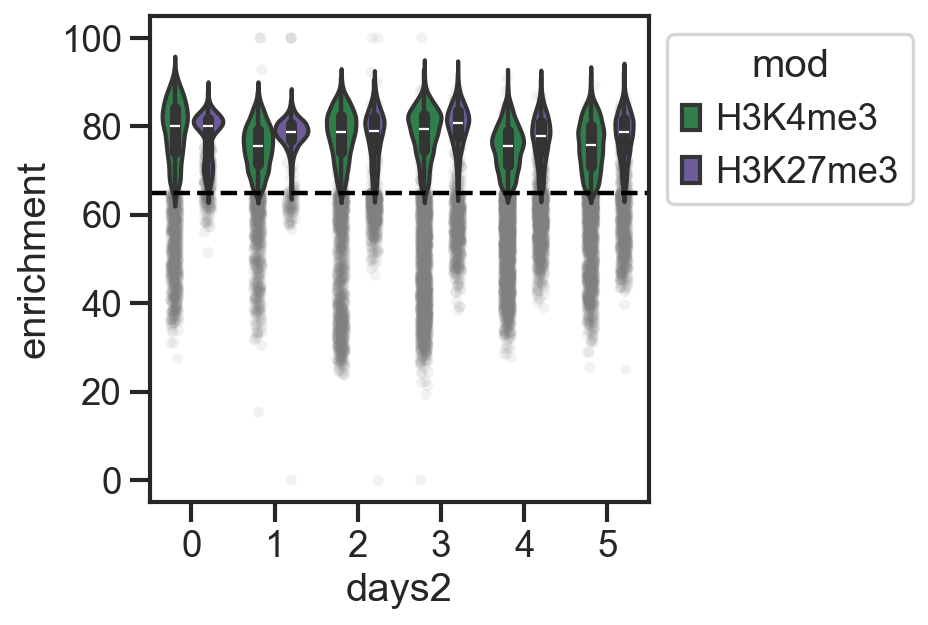

In [52]:
#FigS3a right
ax=sns.stripplot(data=QC[QC['QC']=='bad'], x="days2", y="enrichment", hue="mod", dodge=True, palette=['Grey','Grey'], alpha=0.1, legend=False, zorder=0)
ax=sns.violinplot(data=QC[QC['QC']=='good'], x="days2", y="enrichment", hue="mod", dodge=True, palette=[Green,Purple], zorder=1,inner_kws=dict(box_width=5, whis_width=2))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.axhline(65, ls='--', color='Black', linewidth=2)
plt.savefig('figures/cell_selection_enrichment.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

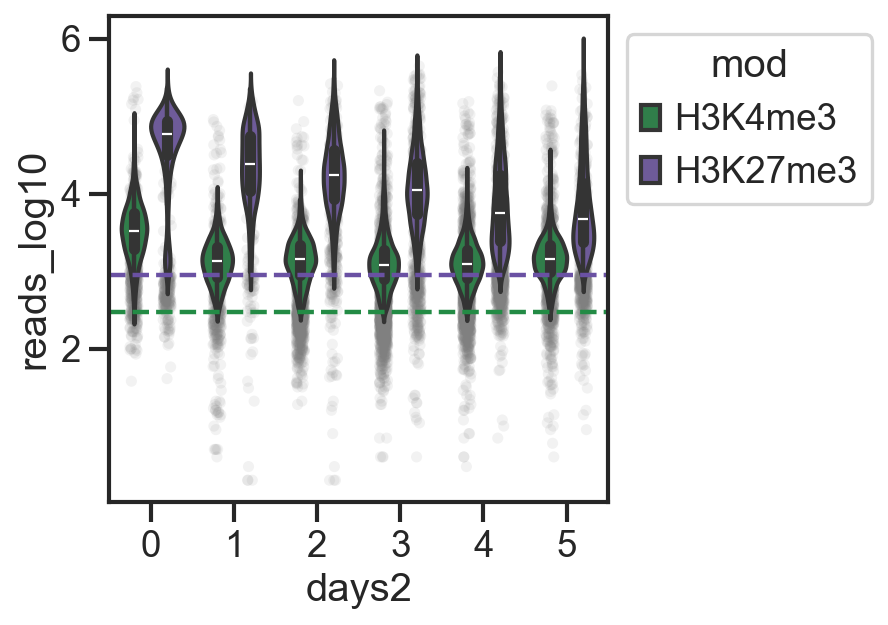

In [53]:
#FigS3a left
ax=sns.stripplot(data=QC[QC['QC']=='bad'], x="days2", y="reads_log10", hue="mod", dodge=True, palette=['Grey','Grey'], alpha=0.1, legend=False, zorder=0)
ax=sns.violinplot(data=QC[QC['QC']=='good'], x="days2", y="reads_log10", hue="mod", dodge=True, palette=[Green,Purple], zorder=1,inner_kws=dict(box_width=5, whis_width=2))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.axhline(2.477, ls='--', color=Green, linewidth=2)
ax.axhline(2.954, ls='--', color=Purple, linewidth=2)
plt.savefig('figures/cell_selection_reads.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

In [58]:
adata=adata[QC[QC['QC']=='good'].index]

In [63]:


def readRawTable(path):
    raw_table = pd.read_csv(path, index_col=0,
                            header = 0, low_memory=True)
    raw_table = raw_table.astype(np.float32).T
    raw_table.index.names = ['bname']
    raw_table = raw_table[~raw_table.index.duplicated(keep='first')]
    return raw_table


In [71]:



def readRawTable(path, index_col=0, chunksize=10_000):
    
    chunks = []
    for chunk in pd.read_csv(path, index_col=index_col, header=0,
                              low_memory=False, chunksize=chunksize):
        # Replace inf with NaN
        chunk = chunk.replace([np.inf, -np.inf], np.nan)

        # Convert all numeric columns to nullable Int32
        num_cols = chunk.select_dtypes(include=["number"]).columns
        for col in num_cols:
            chunk[col] = chunk[col].astype("Int32")

        chunks.append(chunk)

    raw_table=pd.concat(chunks, axis=0).T
    raw_table.index.names = ['bname']
    raw_table = raw_table[~raw_table.index.duplicated(keep='first')]
    return raw_table




In [ ]:
#import chromatin count data on TSS.

#Bed files defining counting windows were prepared using: Fig3_produceTSSlist.ipynb
#Counting was performed using (part of SCMO): bamCountRegions.py input.bam -t 1 -regions countregions.bed -o output.csv -s output_total.csv
#To integrate ChIC layers, continue with script. If table too large, use addChIClayersToAdata.py and change file names in script

In [72]:
k27me3_TSS_raw = readRawTable('input/H3K27me3_10kb_TSS_inside_counts.csv', chunksize=5_000)
k4_TSS_raw = readRawTable('input/H3K4me3_5kb_TSS_counts.csv', chunksize=5_000)


In [75]:
def formatTable(table):
    return table.T.merge(adata.obs['cellnames'],left_index=True,right_index=True,
                         how="right").fillna(0).drop('cellnames',
                                                     axis = 1).T.merge(adata.var['Accession'],
                                                                       left_index=True,right_index=True,
                                                                       how="right").fillna(0).drop('Accession',
                                                                                                   axis=1).reindex(adata.var.index).T


k27me3_TSS_raw_adata = formatTable(k27me3_TSS_raw)
k4_TSS_raw_adata = formatTable(k4_TSS_raw)



adata.layers['k27me3_TSS_raw'] = scipy.sparse.csr_matrix(k27me3_TSS_raw_adata,dtype=np.float32)
adata.layers['k4me3_TSS_raw'] = scipy.sparse.csr_matrix(k4_TSS_raw_adata,dtype=np.float32)


adata.layers['spliced'] = scipy.sparse.csr_matrix(pd.DataFrame(adata.layers['spliced'].toarray()),dtype=np.float32)
adata.layers['unspliced'] = scipy.sparse.csr_matrix(pd.DataFrame(adata.layers['unspliced'].toarray()),dtype=np.float32)

C:\Users\au783837\AppData\Local\Temp\ipykernel_42352\3079199998.py:15: ImplicitModificationWarning: Setting element `.layers['k27me3_TSS_raw']` of view, initializing view as actual.
  adata.layers['k27me3_TSS_raw'] = scipy.sparse.csr_matrix(k27me3_TSS_raw_adata,dtype=np.float32)


In [76]:
results_file = 'output/20230619_allGastruloids_UMAP_celltypes_incChroms.h5ad'
adata.write(results_file, compression='gzip')  # `compression='gzip'` saves disk space, but slows down writing and subsequent reading
